## Exercise 1

# .1

The difference in using linear functions for feature engineering and for function approximation is that in feature engineering, linear functions are used to create new features from the original input data, while in function approximation, linear functions are used to approximate the relationship between the input features and the target variable.

In other words, the linear functions in feature engineering are used to represent the states in a more informative way, while in function approximation, the linear functions are used to model the value function or policy directly.

# .2

semi-gradient for a TD(n) update is given by: 
$$
\nabla_{\mathbf w}\mathcal{L}(\mathbf w)\approx-\bigl(G_t^{(n)}-v(S_t;\mathbf w)\bigr)\nabla_{\mathbf w}v(S_t;\mathbf w)
$$



# .3
The proof for policy improvement theorem in the case of DP relies on the fact that the next chosen policy is the best response to the current value function. In the case of function approximation, we cannot guarantee that the next chosen policy is the best response to the current value function, as the value function is only an approximation. Therefore, we cannot guarantee that the policy improvement theorem holds in the case of function approximation.

# .4
The problem when using function approximation in combination with off-policy learning and bootstrapping is that many states share the same parameters in the function approximation. This can lead to divergence of the learning algorithm, as updates to the parameters based on one state can negatively affect the value estimates for other states that share the same parameters. This is known as the "deadly triad" of function approximation, off-policy learning, and bootstrapping.

## Exercise 2

# 2.1
State-value function for MC is given by:
$$
v(s) = \mathbb{E}[G_t | S_t = s]
$$ 

$$
v(home) = G_8(home) = 0 + \gamma \cdot 0
$$


$$
v(\text{uni})

= \frac{1}{8}\bigl(G_1(\text{uni}) + G_2(\text{uni}) + G_3(\text{uni}) + G_4(\text{uni}) + G_5(\text{uni}) + G_6(\text{uni}) + G_7(\text{uni}) + G_8(\text{uni})\bigr)
$$

$$
= \frac{1}{8}\cdot(1+1+0+1+1+1+1+0)


= \frac{1}{8}\cdot 6


= \frac{6}{8}


= \frac{3}{4}.
$$


State-value function using TD is given by:
$$
v(s) = v(s) + \alpha\bigl(R_{t+1} + \gamma v(S_{t+1}) - v(s)\bigr)
$$

Which at convergence gives us: 
$$
v(s) = R_{t+1} + \gamma v(S_{t+1})
$$ 


$$
v(uni) = (1 + 1 + 0 + 1 + 1 + 1 + 1 + 0) / 8 = 3/4
$$

And 
$$
v(home) = 0 + \gamma \cdot v(uni) = 0 + \gamma \cdot 3/4 = 3\gamma / 4
$$

The difference between the results is from the bootstrapping in TD. In MC we use the actual returns from the whole episode, which shows to be 0 for the trajectory starting at home.

WHile in TD we use the estimated value of the next state, so for the trajectory starting at home, we use the estimated value of uni, which is 3/4, and this gives us a non-zero value for home.

# 2.4

To have a full learned model of the game we need to learn the transition probabilities and the reward function. This is computed using the observed transitions and rewards. e.g. we need the data on the states, actions and rewards to compute the transition probabilities and the reward function.

# 2.5

The definition of the transition probability function is given by:
$$P(s'|s,a) = \mathbb{P}(S_{t+1}=s'|S_t=s,A_t=a)$$

E.g. the probability from taking an action and transitioning to a new state

The reward function is defined as: 
$$R(s,a,s') = \mathbb{E}[r_{t+1} \mid S_t=s, A_t=a, S_{t+1}=s']$$

E.g. the expected reward for taking an action and transitioning to a new state

# 2.9
The reward function differs from the value function in that the reward function is the expected reward for taking an action in a given state and transitioning to a new state, while the value function is the expected return for being in a certain state and following a certain policy. Hence, the value function is often marked by the policy.

value function in DP is given by:
$$
v_\pi(s) = \sum_{a} \pi(a|s) \sum_{s',r} P(s',r|s,a) [r + \gamma v_\pi(s')]
$$

Hence for our problem, the value function for the state "home" is:
$$
1 * (0 + \gamma 1 * 3/4) = \gamma 3/4
$$


And for the state "uni" it is:
$$
1 * (3/4 + \gamma 1 * 0) = 3/4
$$

# 2.12
The state-value function for "uni" is the same for DP, MC and TD. But the state-value function for "home" is $$ \gamma 3/4$$ for DP and TD, while it is 0 for MC. This is because in MC we use the actual returns from the whole episode, which in this case is only one trajectory starting at home.

# 2.13

The state-value function for "uni" under MC using both real data and simulation data is the immediate reward we get from the trajectories starting at uni.
real data: 1 1 0 1 1 1 1 0
simulation data: 1 1 1 1 0 1 1 0

$$ v_{MC}(uni) = \frac{12}{16} = \frac{3}{4} $$

from the simulation data, we have three trajectories starting at home, which gives no immediate rewards, but two of the trajectories gives the discounted reward of $$\gamma$$ after transitioning to uni, which gives us the state-value function for home as:
$$ v_{MC}(home) = \gamma + \gamma / 4 = \frac{2\gamma}{4} = \frac{\gamma}{2} $$


# 2.14

For TD, the state value function for "uni" is the same as for MC as we always go to the terminal state after uni, and the immediate reward is 1.

Since we in TD use bootstrapping, we use the estimated value of the next state to compute the value function for home. Hence, we have:
$$ v_{TD}(home) = 0 + \gamma v_{TD}(uni) = 0 + \gamma \cdot 3/4 = 3\gamma / 4 $$

# 2.15

Only the state-value function for home using MC changes when we use simulation data as well as real data. This is because we get additional trajectories starting at home in the simulation data, which gives us additional rewards that affect the value function for MC where we use the whole episode returns. For TD, we use bootstrapping and the estimated value of the next state, which did not change, due to the simulation data not changing the value function for uni. If the simulation data had changed the value function for uni, then the value function for home using TD would have changed as well.

## Exercise 3
MCTS can be a good idea for a self-driving car, as it simnulate what actions to take in a given state to maximize the driving quality. For example, it can simulate different routes to take, or simulate what actions to take in a given situation, such as when approaching an intersection or when encountering a pedestrian. By simulating different scenarios and evaluating the outcomes, MCTS can help the self-driving car make informed decisions that maximize safety and efficiency.

On the other hand, MCTS can be very computationally expensive, and therefore not a good idea for it too handle tasks that require quick decision making. This is because the real world is obviously very complex, and consists of a continuous state space, which makes it difficult to simulate all possible scenarios and evaluate them in a timely manner.

## Part 2

In [1]:
import gymnasium

env = gymnasium.make('MountainCar-v0', max_episode_steps = 1000)

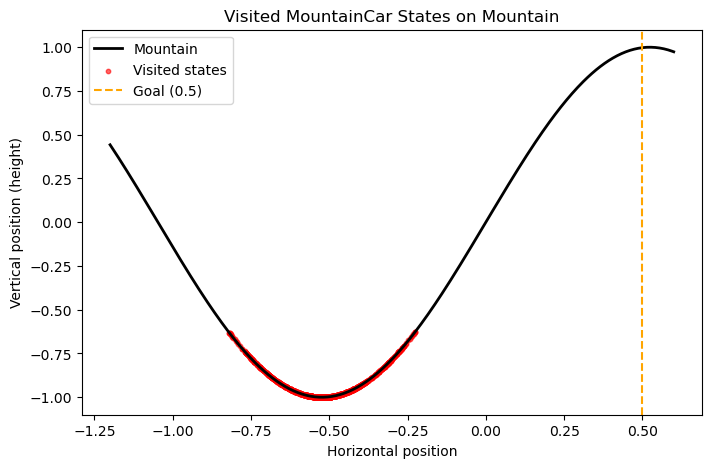

In [2]:
import matplotlib.pyplot as plt
import numpy as np

states = []
state, _ = env.reset()

done = False
while not done:
    states.append(state)
    action = env.action_space.sample()
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

states = np.array(states)

x = np.linspace(-1.2, 0.6, 400)
heights = np.sin(3 * states[:, 0])

plt.figure(figsize=(8, 5))
plt.plot(x, np.sin(3 * x), color="black", linewidth=2, label="Mountain")
plt.scatter(states[:, 0], heights, s=10, alpha=0.6, color="red", label="Visited states")
plt.axvline(0.5, color="orange", linestyle="--", label="Goal (0.5)")
plt.xlabel("Horizontal position")
plt.ylabel("Vertical position (height)")
plt.title("Visited MountainCar States on Mountain")
plt.legend()
plt.show()


In [ ]:
n_pos_bins = 10
n_vel_bins = 10
pos_bins = np.linspace(env.observation_space.low[0], env.observation_space.high[0], n_pos_bins - 1)
vel_bins = np.linspace(env.observation_space.low[1], env.observation_space.high[1], n_vel_bins - 1)

def choose_action(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state[0], state[1], :])

def train_q_learning(episodes=2000, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
    Q = np.zeros((n_pos_bins, n_vel_bins, env.action_space.n))
    rewards = []
    for episode in range(episodes):
        state, _ = env.reset()
        state = discretize_state(state, pos_bins, vel_bins)
        done = False
        total_reward = 0
        while not done:
            action = choose_action(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, pos_bins, vel_bins)
            done = terminated or truncated

            best_next_q = np.max(Q[next_state[0], next_state[1], :])
            Q[state[0], state[1], action] += alpha * (reward + gamma * best_next_q - Q[state[0], state[1], action])

            state = next_state
            total_reward += reward

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        rewards.append(total_reward)
    return Q, rewards


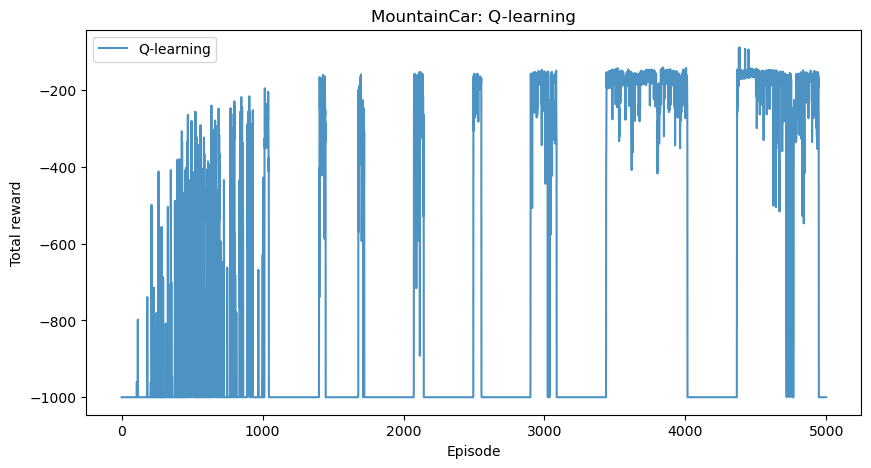

In [4]:
Q_q, rewards_q = train_q_learning()


plt.figure(figsize=(10, 5))
plt.plot(rewards_q, label="Q-learning", alpha=0.8)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("MountainCar: Q-learning")
plt.legend()
plt.show()


In [5]:
bin_settings = [
    (8, 8),
    (12, 12),
    (18, 14),
    (24, 18),
    (30, 30),
]


In [ ]:
def make_bins(n_pos_bins, n_vel_bins):
    pos_bins = np.linspace(-1.2, 0.6, n_pos_bins - 1)
    vel_bins = np.linspace(-0.07, 0.07, n_vel_bins - 1)
    return pos_bins, vel_bins

def discretize_state(state, pos_bins, vel_bins):
    position, velocity = state
    pos_idx = np.digitize(position, pos_bins)
    vel_idx = np.digitize(velocity, vel_bins)
    return (pos_idx, vel_idx)

def tile_encode(state, n_tilings=8, n_tiles=8):
    pos, vel = state
    pos_norm = (pos + 1.2) / 1.8
    vel_norm = (vel + 0.07) / 0.14
    indices = []
    for t in range(n_tilings):
        offset = t / n_tilings
        pos_tile = int((pos_norm + offset / n_tiles) * n_tiles) % n_tiles
        vel_tile = int((vel_norm + offset / n_tiles) * n_tiles) % n_tiles
        indices.append(t * n_tiles * n_tiles + pos_tile * n_tiles + vel_tile)
    return indices

def train_q_learning_with_bins(n_pos_bins, n_vel_bins, episodes=3000, alpha=0.1, gamma=0.99,
                                epsilon=1.0, epsilon_decay=0.999, epsilon_min=0.05):
    pos_bins, vel_bins = make_bins(n_pos_bins, n_vel_bins)
    Q = np.zeros((n_pos_bins, n_vel_bins, env.action_space.n))
    rewards = []
    for episode in range(episodes):
        state, _ = env.reset()
        state = discretize_state(state, pos_bins, vel_bins)
        done = False
        total_reward = 0
        while not done:
            action = choose_action(Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, pos_bins, vel_bins)
            done = terminated or truncated
            best_next_q = np.max(Q[next_state[0], next_state[1], :])
            Q[state[0], state[1], action] += alpha * (reward + gamma * best_next_q - Q[state[0], state[1], action])
            state = next_state
            total_reward += reward
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)
    return Q, rewards


In [ ]:
# --- Run bin size comparison (slow) ---
results = {}
for n_pos_bins, n_vel_bins in bin_settings:
    _, rewards = train_q_learning_with_bins(n_pos_bins, n_vel_bins)
    results[(n_pos_bins, n_vel_bins)] = rewards

def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(12, 6))
for setting, rewards in results.items():
    plt.plot(moving_average(rewards, 100), label=f"{setting[0]}x{setting[1]}")
plt.xlabel("Episode")
plt.ylabel("Average total reward")
plt.title("Q-learning with different discretization sizes")
plt.legend()
plt.show()

for setting, rewards in results.items():
    final_avg = np.mean(rewards[-100:])
    print(f"Bins {setting}: average reward over last 100 episodes = {final_avg:.2f}")


In [ ]:
N_TILINGS = 8
N_TILES = 8
TOTAL_TILES = N_TILINGS * N_TILES * N_TILES

def q_value(w, tiles, action):
    return w[action, tiles].sum()

def choose_action_tile(w, tiles, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return max(range(env.action_space.n), key=lambda a: q_value(w, tiles, a))

def train_q_learning_with_tiles(
    episodes=2000,
    alpha=0.1 / N_TILINGS,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.05,
):
    w = np.zeros((env.action_space.n, TOTAL_TILES))
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        tiles = tile_encode(state)
        done = False
        total_reward = 0

        while not done:
            action = choose_action_tile(w, tiles, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_tiles = tile_encode(next_state)
            done = terminated or truncated

            current_q = q_value(w, tiles, action)
            if done:
                target = reward
            else:
                target = reward + gamma * max(q_value(w, next_tiles, a) for a in range(env.action_space.n))

            delta = target - current_q
            w[action, tiles] += alpha * delta

            tiles = next_tiles
            total_reward += reward

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)
    return w, rewards


# Train both
Q_table, rewards_table = train_q_learning()
w_tile, rewards_tile = train_q_learning_with_tiles()

# Moving average helper
def moving_average(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards_table), label="Tabular Q-learning", alpha=0.8)
plt.plot(moving_average(rewards_tile), label="Tile coding Q-learning", alpha=0.8)
plt.axhline(-200, color='green', linestyle='--', label='Reasonable performance (-200)')
plt.xlabel("Episode")
plt.ylabel("Total reward (50-ep average)")
plt.title("Tabular vs Tile Coding Q-learning on MountainCar")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


As we see, the Q-learning gets the best rewards when we use a discretization step of 24 for position and 18. (out of the ones that we tested)

# 4.3
Another form of feature engineering is to normalize the input features to make both features contribute more evenly, as well as improving the numerical stability.

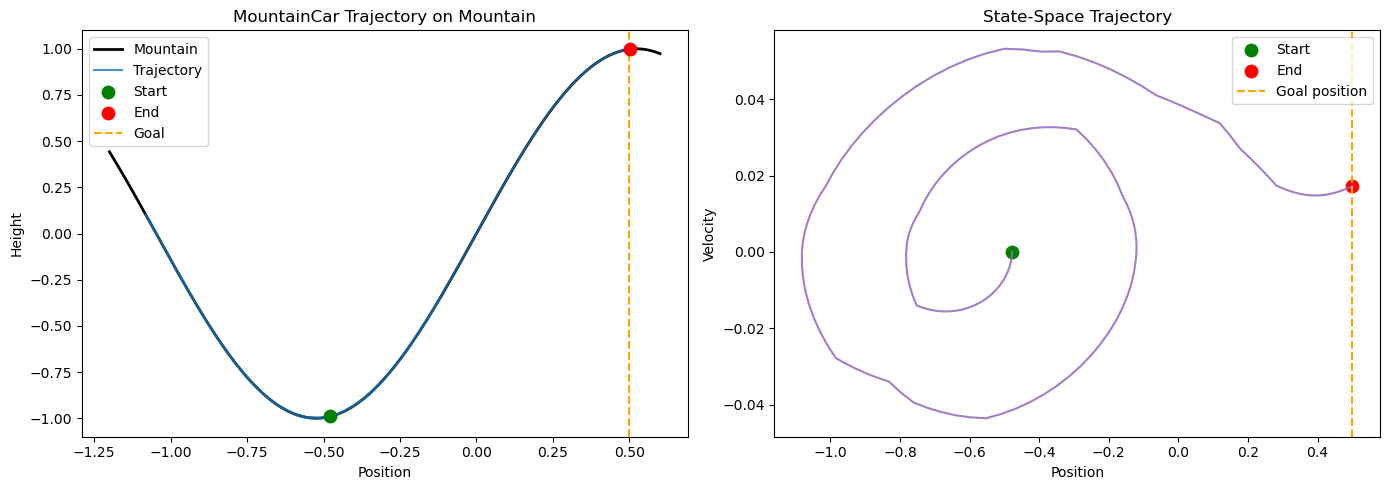

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

env = gym.make("MountainCar-v0", max_episode_steps=1000)

def run_greedy_episode(Q, pos_bins, vel_bins):
    def discretize_state(state):
        position, velocity = state
        pos_idx = np.digitize(position, pos_bins)
        vel_idx = np.digitize(velocity, vel_bins)
        return (pos_idx, vel_idx)

    state, _ = env.reset()
    done = False

    states = [state.copy()]
    actions = []

    while not done:
        ds = discretize_state(state)
        action = np.argmax(Q[ds[0], ds[1], :])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        actions.append(action)
        states.append(next_state.copy())
        state = next_state

    return np.array(states), np.array(actions)

states, actions = run_greedy_episode(Q_q, pos_bins, vel_bins)

positions = states[:, 0]
velocities = states[:, 1]

x = np.linspace(-1.2, 0.6, 400)
y = np.sin(3 * x)
traj_y = np.sin(3 * positions)
goal_position = 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, y, color="black", linewidth=4, label="Mountain")
axes[0].plot(positions, traj_y, color="tab:yellow", alpha=0.8, label="Trajectory")
axes[0].scatter(positions[0], traj_y[0], color="green", s=80, label="Start", zorder=3)
axes[0].scatter(positions[-1], traj_y[-1], color="red", s=80, label="End", zorder=3)
axes[0].axvline(goal_position, color="orange", linestyle="--", label="Goal")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Height")
axes[0].set_title("MountainCar Trajectory on Mountain")
axes[0].legend()

axes[1].plot(positions, velocities, color="tab:purple", alpha=0.85)
axes[1].scatter(positions[0], velocities[0], color="green", s=80, label="Start")
axes[1].scatter(positions[-1], velocities[-1], color="red", s=80, label="End")
axes[1].axvline(goal_position, color="orange", linestyle="--", label="Goal position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Velocity")
axes[1].set_title("State-Space Trajectory")
axes[1].legend()

plt.tight_layout()
plt.show()


# Exercise 5
5.1


In [ ]:
from collections import defaultdict
import numpy as np
data = np.loadtxt("powered_flight.txt", dtype=int)

# Work on copies so the raw dataset remains 1-indexed for later cells.
s1 = data[:, 0].copy()
s2 = data[:, 1].copy()
a = data[:, 2].copy()
r  = data[:, 3].copy()
ns1 = data[:, 4].copy()
ns2 = data[:, 5].copy()

n_s1 = int(data[:, [0, 4]].max())   # 25
n_s2 = int(data[:, [1, 5]].max())   # 64
n_a  = int(data[:, 2].max())        # 2

# Convert local arrays to 0-indexed for model-estimation dictionaries.
s1 -= 1
s2 -= 1
a  -= 1
ns1 -= 1
ns2 -= 1

transition_counts = defaultdict(int)
sa_counts = defaultdict(int)
reward_sums = defaultdict(float)

for i in range(len(data)):
    s = (s1[i], s2[i])
    action = a[i]
    sp = (ns1[i], ns2[i])  # next state
    
    transition_counts[(s, action, sp)] += 1
    sa_counts[(s, action)] += 1
    reward_sums[(s, action)] += r[i]

# P(s' | s, a) - transition probabilities
P = defaultdict(float)
for (s, act, sp), count in transition_counts.items():
    P[(s, act, sp)] = count / sa_counts[(s, act)]

# Reward function R(s, a)
R = defaultdict(float)
for (s, act), count in sa_counts.items():
    R[(s, act)] = reward_sums[(s, act)] / count

In [11]:
import sys, os, subprocess
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Install the skyscraper env if needed
subprocess.run([sys.executable, "-m", "pip", "install", "-e", "skyscraper", "-q"], check=True)

import gymnasium as gym
import skyscraper
sky_env = gym.make("skyscraper/GridWorld-v0")

# Environment bounds: step() crashes if row>31 or col>63 (0-indexed)
Q_ROWS, Q_COLS = 32, 64

# --- Rebuild model from powered_flight.txt data ---
model = {}
visited_sa = []

def update_model(s, a, r, sp):
    key = (s[0], s[1], a)
    if key not in model:
        model[key] = {"next_state_counts": defaultdict(int), "reward_sum": 0.0, "visit_count": 0}
        visited_sa.append(key)
    model[key]["next_state_counts"][sp] += 1
    model[key]["reward_sum"] += r
    model[key]["visit_count"] += 1

def sample_from_model(s, a):
    entry = model[(s[0], s[1], a)]
    next_states = list(entry["next_state_counts"].keys())
    counts = np.array(list(entry["next_state_counts"].values()), dtype=float)
    probs = counts / counts.sum()
    sp = next_states[np.random.choice(len(next_states), p=probs)]
    r = entry["reward_sum"] / entry["visit_count"]
    return r, sp

# Pre-populate the model from the offline dataset
for row in data:
    update_model((int(row[0])-1, int(row[1])-1), int(row[2])-1,
                 float(row[3]), (int(row[4])-1, int(row[5])-1))
print(f"Model pre-populated: {len(visited_sa)} (s,a) pairs from powered_flight.txt")

# --- Online Dyna-Q: real env steps + model-based planning ---
def obs_to_state(obs): # Convert observation to state coordinates
    pos = obs["agent"]["pos"]
    return (int(pos[0]), int(pos[1]))

def choose_action_eps(Q, s, epsilon): # epsilon-greedy policy to handle exploration in real env steps
    if np.random.rand() < epsilon:
        return sky_env.action_space.sample()
    return int(np.argmax(Q[s[0], s[1], :]))

Q_dyna = np.zeros((Q_ROWS, Q_COLS, n_a))
episode_rewards = []
alpha, gamma = 0.1, 0.99
epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
n_planning_steps = 10
n_episodes = 300
max_steps_per_ep = 300

for ep in range(n_episodes):
    obs, _ = sky_env.reset()
    s = obs_to_state(obs)
    total_reward = 0

    for _ in range(max_steps_per_ep):
        a = choose_action_eps(Q_dyna, s, epsilon)
        next_obs, r, terminated, truncated, _ = sky_env.step(a)
        sp = obs_to_state(next_obs)

        # Real-experience Q update
        Q_dyna[s[0], s[1], a] += alpha * (
            r + gamma * np.max(Q_dyna[sp[0], sp[1], :]) - Q_dyna[s[0], s[1], a]
        )

        # Update model with this real transition
        update_model(s, a, r, sp)

        # Planning steps from the model (pre-populated + online data)
        for _ in range(n_planning_steps):
            k = visited_sa[np.random.randint(len(visited_sa))]
            s_pl, a_pl = (k[0], k[1]), k[2]
            r_pl, sp_pl = sample_from_model(s_pl, a_pl)
            Q_dyna[s_pl[0], s_pl[1], a_pl] += alpha * (
                r_pl + gamma * np.max(Q_dyna[sp_pl[0], sp_pl[1], :]) - Q_dyna[s_pl[0], s_pl[1], a_pl]
            )

        total_reward += r
        s = sp
        if terminated or truncated:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)

policy = np.argmax(Q_dyna, axis=2) + 1
print("Learned policy (1-indexed actions):")
print(policy[:n_s1, :n_s2])  # print only the region covered by the data

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward (1 = goal reached)")
plt.title("Dyna-Q: real SkyscraperEnv + planning from powered_flight.txt model")
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'data' is not defined

Trajectory in environment coordinates (0-indexed):
[(13, 5), (14, 8), (15, 11), (17, 13), (18, 16), (18, 19), (16, 16), (16, 18), (16, 20), (14, 22), (12, 19), (10, 21), (9, 24), (8, 21), (7, 24), (6, 21), (5, 24), (4, 27), (3, 30), (4, 32), (5, 34), (6, 36), (7, 38), (8, 40), (7, 43), (6, 46), (5, 49), (4, 52), (3, 49), (2, 52), (1, 56), (2, 60), (3, 58), (4, 55), (5, 58), (6, 55), (7, 58), (8, 55), (9, 58), (10, 61), (13, 58), (14, 54)]

Trajectory in file coordinates (1-indexed):
[(14, 6), (15, 9), (16, 12), (18, 14), (19, 17), (19, 20), (17, 17), (17, 19), (17, 21), (15, 23), (13, 20), (11, 22), (10, 25), (9, 22), (8, 25), (7, 22), (6, 25), (5, 28), (4, 31), (5, 33), (6, 35), (7, 37), (8, 39), (9, 41), (8, 44), (7, 47), (6, 50), (5, 53), (4, 50), (3, 53), (2, 57), (3, 61), (4, 59), (5, 56), (6, 59), (7, 56), (8, 59), (9, 56), (10, 59), (11, 62), (14, 59), (15, 55)]

Actions along trajectory (1-indexed):
[2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

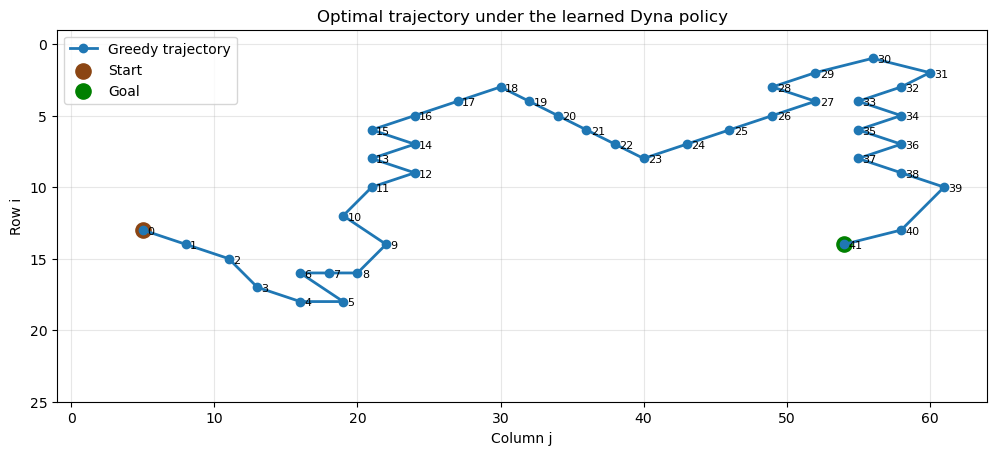

In [ ]:
# Plot the greedy trajectory learned by Dyna
import numpy as np
import matplotlib.pyplot as plt

# Coordinates from the PDF are in 0-indexed environment coordinates.
start_state_env = (13, 5)
goal_state_env = (14, 54)

def available_actions(s):
    return [a for a in range(n_a) if (s[0], s[1], a) in model]

def greedy_action_from_model(s):
    actions = available_actions(s)

    if not actions:
        return None

    return max(actions, key=lambda a: Q_dyna[s[0], s[1], a])

def most_likely_transition(s, a):
    key = (s[0], s[1], a)
    entry = model[key]
    sp = max(entry["next_state_counts"], key=entry["next_state_counts"].get)
    r = entry["reward_sum"] / entry["visit_count"]

    return r, sp

def rollout_greedy_trajectory(start_state, goal_state, max_steps=200):
    trajectory = [start_state]
    actions = []
    s = start_state

    for _ in range(max_steps):
        if s == goal_state:
            break

        a = greedy_action_from_model(s)

        if a is None:
            print(f"Stopped rollout at state {s} because the learned model has no outgoing actions there.")
            break

        actions.append(a)

        r, sp = most_likely_transition(s, a)
        trajectory.append(sp)

        if r == 1 or sp == goal_state:
            break

        if sp in trajectory[:-1]:
            print("Loop detected before reaching the goal.")
            break

        s = sp

    return trajectory, actions

# Model states are now also 0-indexed, so no offset conversion is needed.
trajectory_env, actions_0idx = rollout_greedy_trajectory(start_state_env, goal_state_env)
trajectory_file = [(s[0] + 1, s[1] + 1) for s in trajectory_env]
actions_1idx = [a + 1 for a in actions_0idx]

print("Trajectory in environment coordinates (0-indexed):")
print(trajectory_env)
print("\nTrajectory in file coordinates (1-indexed):")
print(trajectory_file)
print("\nActions along trajectory (1-indexed):")
print(actions_1idx)
print("\nReached goal:", trajectory_env[-1] == goal_state_env)

rows = [s[0] for s in trajectory_env]
cols = [s[1] for s in trajectory_env]

plt.figure(figsize=(12, 6))
plt.plot(cols, rows, marker="o", linewidth=2, color="tab:blue", label="Greedy trajectory")
plt.scatter(start_state_env[1], start_state_env[0], color="saddlebrown", s=120, label="Start")
plt.scatter(goal_state_env[1], goal_state_env[0], color="green", s=120, label="Goal")

for step, (row, col) in enumerate(trajectory_env):
    plt.text(col + 0.3, row + 0.3, str(step), fontsize=8)

plt.gca().invert_yaxis()
plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(-1, n_s2)
plt.ylim(n_s1, -1)
plt.xlabel("Column j")
plt.ylabel("Row i")
plt.title("Optimal trajectory under the learned Dyna policy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5.4
Run Dyna-Q with different numbers of planning simulations (`n_planning_steps`) and compare the results.

Result from this run: all tested values (`0, 1, 5, 10, 20, 50`) reached the goal in 15 greedy steps.
Higher planning counts gave smaller TD error, with `20` and `50` giving near-zero mean absolute TD error in the last updates.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

sky_env_54 = gym.make("skyscraper/GridWorld-v0")

planning_steps_list = [0, 1, 5, 10, 20, 50]
simple_results = []
trajectory_results = {}
policy_results = {}

def _build_fresh_model():
    m, v = {}, []
    for row in data:
        key = (int(row[0])-1, int(row[1])-1, int(row[2])-1)
        sp = (int(row[4])-1, int(row[5])-1)
        r = float(row[3])
        if key not in m:
            m[key] = {"next_state_counts": defaultdict(int), "reward_sum": 0.0, "visit_count": 0}
            v.append(key)
        m[key]["next_state_counts"][sp] += 1
        m[key]["reward_sum"] += r
        m[key]["visit_count"] += 1
    return m, v

def _sample(m, key):
    entry = m[key]
    next_states = list(entry["next_state_counts"].keys())
    counts = np.array(list(entry["next_state_counts"].values()), dtype=float)
    sp = next_states[np.random.choice(len(next_states), p=counts/counts.sum())]
    r = entry["reward_sum"] / entry["visit_count"]
    return r, sp

for n_plan in planning_steps_list:
    np.random.seed(0)
    m, v = _build_fresh_model()
    Q_r = np.zeros((Q_ROWS, Q_COLS, n_a))
    ep_rewards = []
    eps = 1.0

    for ep in range(300):
        obs, _ = sky_env_54.reset()
        s = (int(obs["agent"]["pos"][0]), int(obs["agent"]["pos"][1]))
        total_r = 0

        for _ in range(300):
            a = sky_env_54.action_space.sample() if np.random.rand() < eps else int(np.argmax(Q_r[s[0], s[1], :]))
            next_obs, r, terminated, truncated, _ = sky_env_54.step(a)
            sp = (int(next_obs["agent"]["pos"][0]), int(next_obs["agent"]["pos"][1]))

            Q_r[s[0], s[1], a] += 0.1 * (r + 0.99 * np.max(Q_r[sp[0], sp[1], :]) - Q_r[s[0], s[1], a])

            key = (s[0], s[1], a)
            if key not in m:
                m[key] = {"next_state_counts": defaultdict(int), "reward_sum": 0.0, "visit_count": 0}
                v.append(key)
            m[key]["next_state_counts"][sp] += 1
            m[key]["reward_sum"] += r
            m[key]["visit_count"] += 1

            for _ in range(n_plan):
                k = v[np.random.randint(len(v))]
                r_pl, sp_pl = _sample(m, k)
                s_pl = (k[0], k[1])
                Q_r[s_pl[0], s_pl[1], k[2]] += 0.1 * (
                    r_pl + 0.99 * np.max(Q_r[sp_pl[0], sp_pl[1], :]) - Q_r[s_pl[0], s_pl[1], k[2]]
                )

            total_r += r
            s = sp
            if terminated or truncated:
                break

        eps = max(0.05, eps * 0.995)
        ep_rewards.append(total_r)

    # Temporarily swap globals so rollout_greedy_trajectory uses this run's model
    Q_dyna_saved, model_saved, visited_sa_saved = Q_dyna, model, visited_sa
    Q_dyna, model, visited_sa = Q_r, m, v  # noqa
    traj, acts = rollout_greedy_trajectory(start_state_env, goal_state_env, max_steps=300)
    Q_dyna, model, visited_sa = Q_dyna_saved, model_saved, visited_sa_saved

    simple_results.append((n_plan, traj[-1] == goal_state_env, len(acts), ep_rewards))
    trajectory_results[n_plan] = traj
    policy_results[n_plan] = np.argmax(Q_r, axis=2)

# --- Results table ---
print("Dyna-Q with real SkyscraperEnv + model from powered_flight.txt")
print(f"{'n_plan':>6} | {'reached_goal':>12} | {'steps':>5} | {'avg_reward_last50':>17}")
print("-" * 52)
for n_plan, reached, steps, ep_rews in simple_results:
    last50 = float(np.mean(ep_rews[-50:]))
    print(f"{n_plan:>6} | {str(reached):>12} | {steps:>5} | {last50:>17.3f}")

# --- Learning curves ---
plt.figure(figsize=(12, 5))
for n_plan, _, _, ep_rews in simple_results:
    w = np.convolve(ep_rews, np.ones(20)/20, mode='valid')
    plt.plot(w, label=f'n_plan = {n_plan}')
plt.xlabel("Episode")
plt.ylabel("Avg reward (20-ep window)")
plt.title("Dyna-Q: learning speed vs n_planning_steps (real env + offline model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NamespaceNotFound: Namespace skyscraper not found. Have you installed the proper package for skyscraper?